## Практическое задание №4
#### по дисциплине "Введение в анализ данных"

*Работу выполнил*: Евсеев Григорий, 3826Б1ПМад1

Работа выполнена с использованием IDE Visual Studio Code.

### Часть 1.

Вспомогательная функция для импорта данных

In [1]:
import xlrd

def importData(bookName, sheetInd):
    res = []
    book = xlrd.open_workbook(bookName)
    sheet = book.sheet_by_index(sheetInd)
    for i in range(1, sheet.nrows):
        res.append(sheet.row_values(i, 0, sheet.ncols))
    return res

examsData = importData('04_Экзамены.xlsx', 0)

Преобразование данных:

In [2]:
types = {0: "Пол", 1: "Расовая группа", 2: "Образование родителей",
         3: "Наличие льгот", 4: "Подготовительный курс",
         5: "Оценка по математике", 6: "Оценка по чтению", 7: "Оценка по письму"}

genderTypes = {"male": "М", "female": "Ж"}
raceTypes = {"group A": 0, "group B": 1, "group C": 2, "group D": 3, "group E": 4}
edTypes = {"some high school": 0, "high school": 1, "some college": 2,
           "associate's degree": 3, "bachelor's degree": 4, "master's degree": 5}
lunchTypes = {"standard": "нет", "free/reduced": "да"}
prepTypes = {"none": "нет", "completed": "да"}

for sample in examsData:
    sample[0] = genderTypes[sample[0]]
    sample[1] = raceTypes[sample[1]]
    sample[2] = edTypes[sample[2]]
    sample[3] = lunchTypes[sample[3]]
    sample[4] = prepTypes[sample[4]]

def dataByType(data, type):
    res = []
    for rec in data:
        res.append(rec[type])
    return res

numData = [5, 6, 7]

Числовые характеристики многомерных данных:

In [3]:
import matplotlib.pyplot as plt
import numpy as np

scores = []
Mscores = []
for i in numData:
    scores.append(dataByType(examsData, i))
    Mscores.append(np.mean(dataByType(examsData, i)))

scoresCov = np.cov(scores)
scoresCorr = np.corrcoef(scores)

print("Математическое ожидание оценок по соответвующим предметам = " + str(Mscores))
print("Ковариационная матрица = \n" + str(scoresCov))
print("Матрица коэффициентов корреляции = \n" + str(scoresCorr))

print("Смещенная оценка дисперсии оценок по математике = " + str(np.var(dataByType(examsData, 5))))
print("Несмещенная оценка дисперсии оценок по математике = " + 
      str(np.var(dataByType(examsData, 5), ddof=1)))


Математическое ожидание оценок по соответвующим предметам = [np.float64(66.089), np.float64(69.169), np.float64(68.054)]
Ковариационная матрица = 
[[229.918998   180.99895796 184.93913313]
 [180.99895796 213.1656046  211.78666066]
 [184.93913313 211.78666066 230.90799199]]
Матрица коэффициентов корреляции = 
[[1.         0.81757966 0.80264205]
 [0.81757966 1.         0.95459808]
 [0.80264205 0.95459808 1.        ]]
Смещенная оценка дисперсии оценок по математике = 229.68907899999996
Несмещенная оценка дисперсии оценок по математике = 229.91899799799796


Построение диаграмм рассеивания:

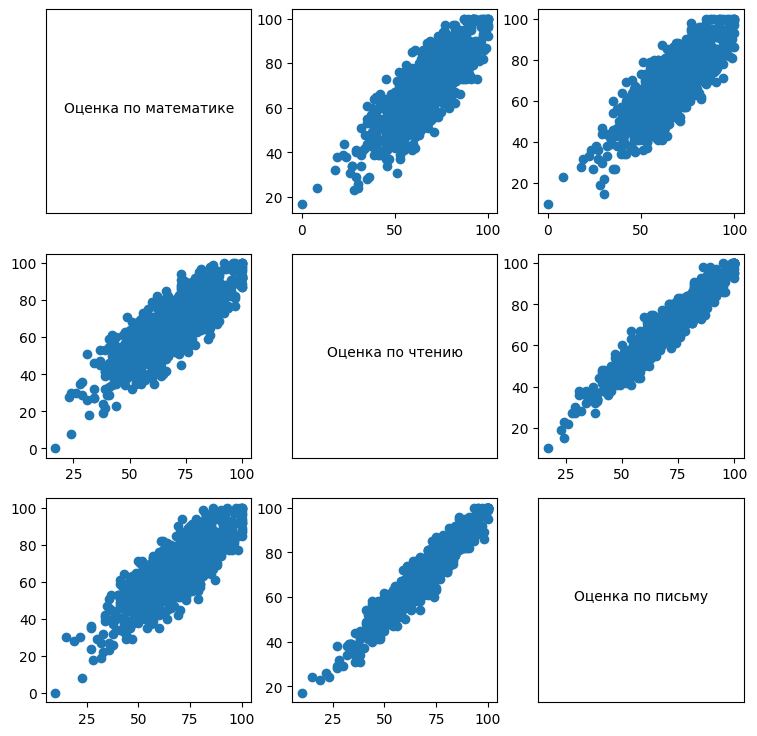

In [4]:
def scatterMatrix(data, ind, names):
    fig, axes = plt.subplots(len(ind), len(ind),
                             figsize=(3 * len(ind), 3 * len(ind)))
    for i in range(len(ind)):
        for j in range(len(ind)):
            if (i == j):
                axes[i][j].annotate(types[ind[i]], (0.5, 0.5), ha="center")
                axes[i][j].xaxis.set_visible(False)
                axes[i][j].yaxis.set_visible(False)
            else:
                axes[i][j].scatter(dataByType(data, ind[i]), dataByType(data, ind[j]),)
    plt.show()

scatterMatrix(examsData, numData, types)

Построение диаграмм рассеивания для качественных данных:

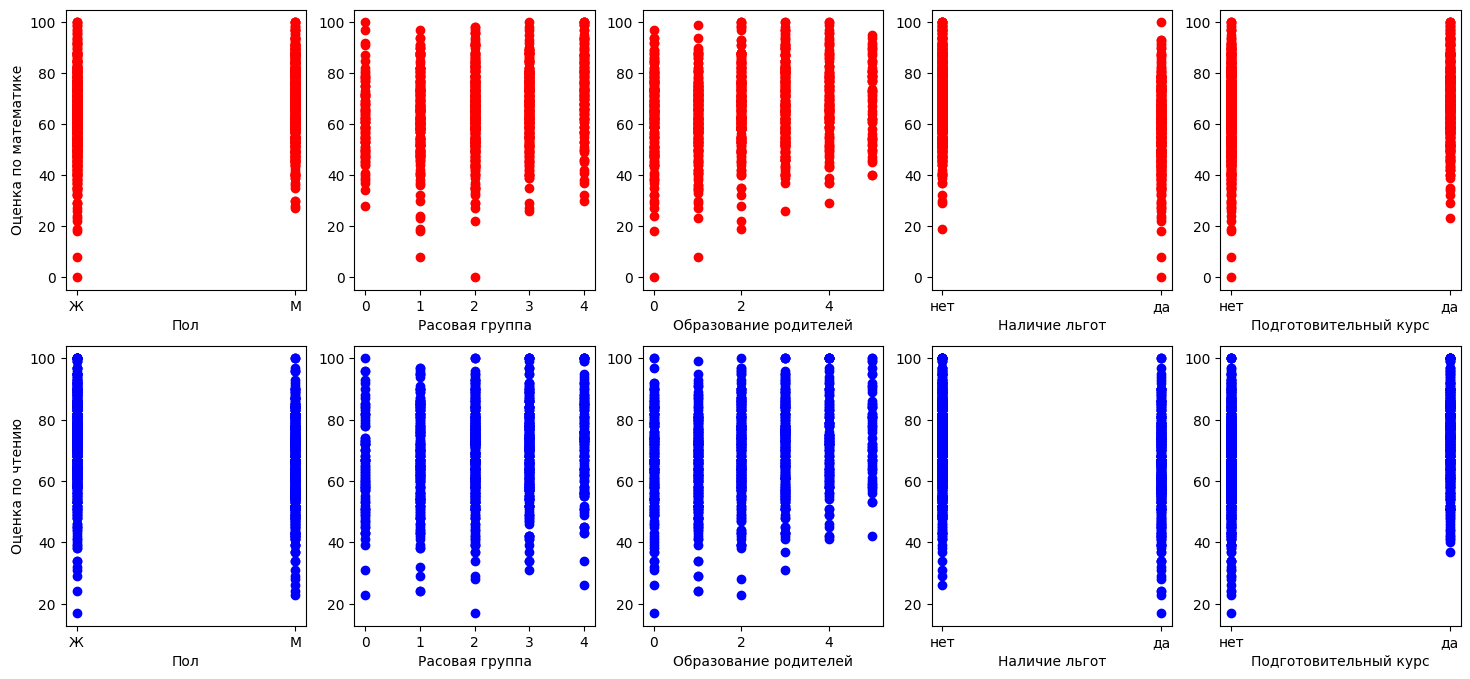

In [5]:
colors = ['red', 'blue']
fig, axes = plt.subplots(2, 5, figsize = (18, 8))
for i in range(5):
    for j in range(2):
        axes[j][i].scatter(dataByType(examsData, i), dataByType(examsData, 5 + j), c = colors[j])
        axes[j][i].set_xlabel(types[i])
        if (i == 0):
            axes[j][i].set_ylabel(types[5 + j])

plt.show()


Аналогичные действия выполнили для другого файла, `04_КлиентыТЦ.xlsx`

Математическое ожидание = [np.float64(38.85), np.float64(60.56), np.float64(50.2)]
Ковариационная матрица = 
[[ 195.13316583   -4.54874372 -118.04020101]
 [  -4.54874372  689.83557789    6.71658291]
 [-118.04020101    6.71658291  666.85427136]]
Матрица коэффициентов корреляции = 
[[ 1.         -0.01239804 -0.32722685]
 [-0.01239804  1.          0.00990285]
 [-0.32722685  0.00990285  1.        ]]


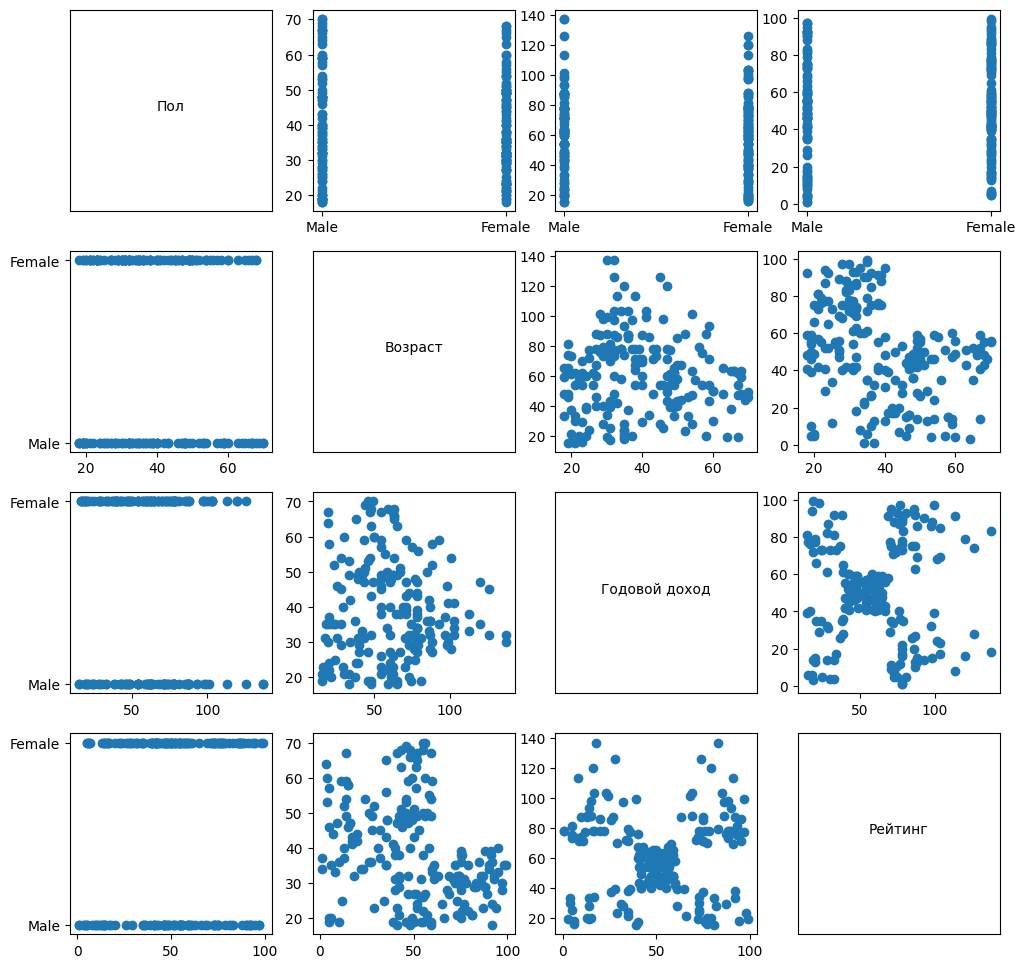

In [6]:
mallData = importData('04_КлиентыТЦ.xlsx', 0)
types = {0:"Пол", 1:"Возраст", 2:"Годовой доход", 3:"Рейтинг"}
numData = [1, 2, 3]

mallNum = []
Mmalls = []
for i in numData:
    mallNum.append(dataByType(mallData, i))
    Mmalls.append(np.mean(dataByType(mallData, i)))

mallCov = np.cov(mallNum)
mallCorr = np.corrcoef(mallNum)
print("Математическое ожидание = " + str(Mmalls))
print("Ковариационная матрица = \n" + str(mallCov))
print("Матрица коэффициентов корреляции = \n" + str(mallCorr))

scatterMatrix(mallData, [0, 1, 2, 3], types)

### Часть 2.

Импорт данных и библиотек:

In [7]:
import xlrd
import numpy as np
import matplotlib.pyplot as plt

def importData(bookName, sheetInd):
    res = []
    book = xlrd.open_workbook(bookName)
    sheet = book.sheet_by_index(sheetInd)
    for i in range(1, sheet.nrows):
        res.append(sheet.row_values(i, 0, sheet.ncols))
    return res

autoData = importData('02_Автоаварии.xlsx', 0)

print("Всего записей:", len(autoData))


Всего записей: 5000


Словарь типов:

In [8]:
types = {
    3: "Класс серьезности аварии", 
    14: "Температура воздуха", 
    16: "Влажность воздуха",
    18: "Видимость дороги",
    20: "Скорость ветра",
    23: "Наличие лежачего полицейского",
    24: "Наличие перекрестка",
    25: "Наличие знака «Уступи дорогу»",
    26: "Наличие транспортная развязка",
    27: "Наличие знака «Нет выхода»",
    28: "Наличие железнодорожных путией",
    29: "Наличие кругового движения",
    30: "Наличие остановки транспорта",
    31: "Наличие знака «Стоп»",
    32: "Наличие дорожного заужения",
    33: "Наличие светофора"
}

Вспомогательная функция, возвращающая наблюдения для конкретного показателя:

In [9]:
def dataByType(data, type):
    res = []
    for rec in data:
        res.append(rec[type])
    return res

numData = [3, 18, 20, 16, 14]

q_ind = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

Обработка пропущенных значений и преобразование в тип `float`:

In [10]:
def toFloat(v):
    try:
        return float(v)
    except (ValueError, TypeError):
        return None

filteredData = []
for row in autoData:
    ok = True
    for idx in numData:
        if toFloat(row[idx]) is None:
            ok = False
            break

    if ok:
        filteredData.append(row)

print("Осталось записей после обработки пропущенных значений: ", len(filteredData))


Осталось записей после обработки пропущенных значений:  4519


#### Задание 1: вычисление числовых характеристик

In [11]:
scores = []
Mscores = []

for i in numData:
    vals = [toFloat(v) for v in dataByType(filteredData, i)]
    scores.append(vals)
    Mscores.append(np.mean(vals))

scoresCov = np.cov(scores)
scoresCorr = np.corrcoef(scores)

print("Математическое ожидание по соответсвующим показателям = " + str(Mscores))
print("Ковариационная матрица = \n" + str(scoresCov))
print("Матрица коэффициентов корреляции = \n" + str(scoresCorr))
print("Смещенная оценка дисперсии степени серьезности аварии = " +
      str(np.var([toFloat(v) for v in dataByType(filteredData, 3)])))
print("несмещенная оценка дисперсии степени серьезности аварии = " +
      str(np.var([toFloat(v) for v in dataByType(filteredData, 3)], ddof = 1)))

Математическое ожидание по соответсвующим показателям = [np.float64(2.422438592608984), np.float64(9.469772073467581), np.float64(9.410245629564063), np.float64(51.027660986944014), np.float64(70.28758574905952)]
Ковариационная матрица = 
[[ 2.47579621e-01  3.82924107e-02  1.79756771e-01  4.48914382e-01
  -1.04471269e-01]
 [ 3.82924107e-02  3.42579258e+00  4.35475775e-01 -1.78702792e+01
   1.56500651e+01]
 [ 1.79756771e-01  4.35475775e-01  1.86122213e+01 -3.45145655e+00
  -1.40489713e+00]
 [ 4.48914382e-01 -1.78702792e+01 -3.45145655e+00  5.64037969e+02
  -3.71785181e+02]
 [-1.04471269e-01  1.56500651e+01 -1.40489713e+00 -3.71785181e+02
   3.42310441e+02]]
Матрица коэффициентов корреляции = 
[[ 1.          0.04157907  0.08373918  0.03798848 -0.01134826]
 [ 0.04157907  1.          0.05453614 -0.40653378  0.45700983]
 [ 0.08373918  0.05453614  1.         -0.03368598 -0.01760092]
 [ 0.03798848 -0.40653378 -0.03368598  1.         -0.84611196]
 [-0.01134826  0.45700983 -0.01760092 -0.846111

#### Задание 2. Построение диаграмм рассеивания для всевозможных случайных величин

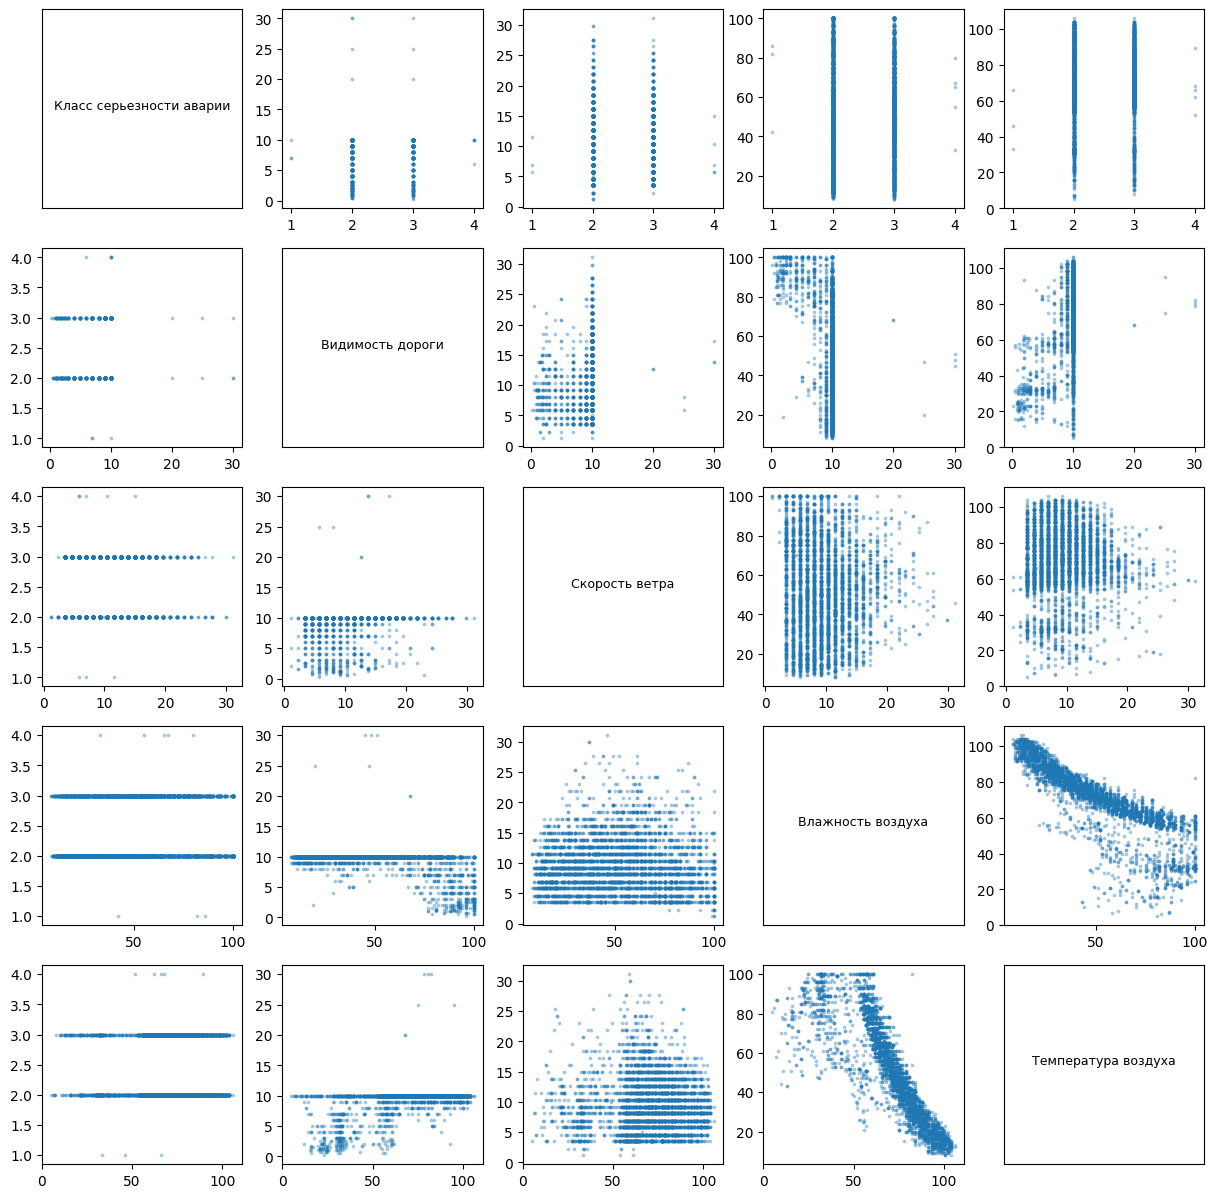

In [12]:
def scatterMatrix(data, ind, names):
    fig, axes = plt.subplots(len(ind), len(ind),
                             figsize=(3 * len(ind), 3 * len(ind)))
    for i in range(len(ind)):
        for j in range(len(ind)):
            if (i == j):
                axes[i][j].annotate(names[ind[i]], (0.5, 0.5),
                                    ha="center", fontsize=9)
                axes[i][j].xaxis.set_visible(False)
                axes[i][j].yaxis.set_visible(False)
            else:
                x = [toFloat(v) for v in dataByType(data, ind[i])]
                y = [toFloat(v) for v in dataByType(data, ind[j])]
                axes[i][j].scatter(x, y, s=3, alpha=0.3)
    plt.show()

scatterMatrix(filteredData, numData, types)

#### Задание 3. Диграммы рассеивания для определения зависимости величины $\chi$

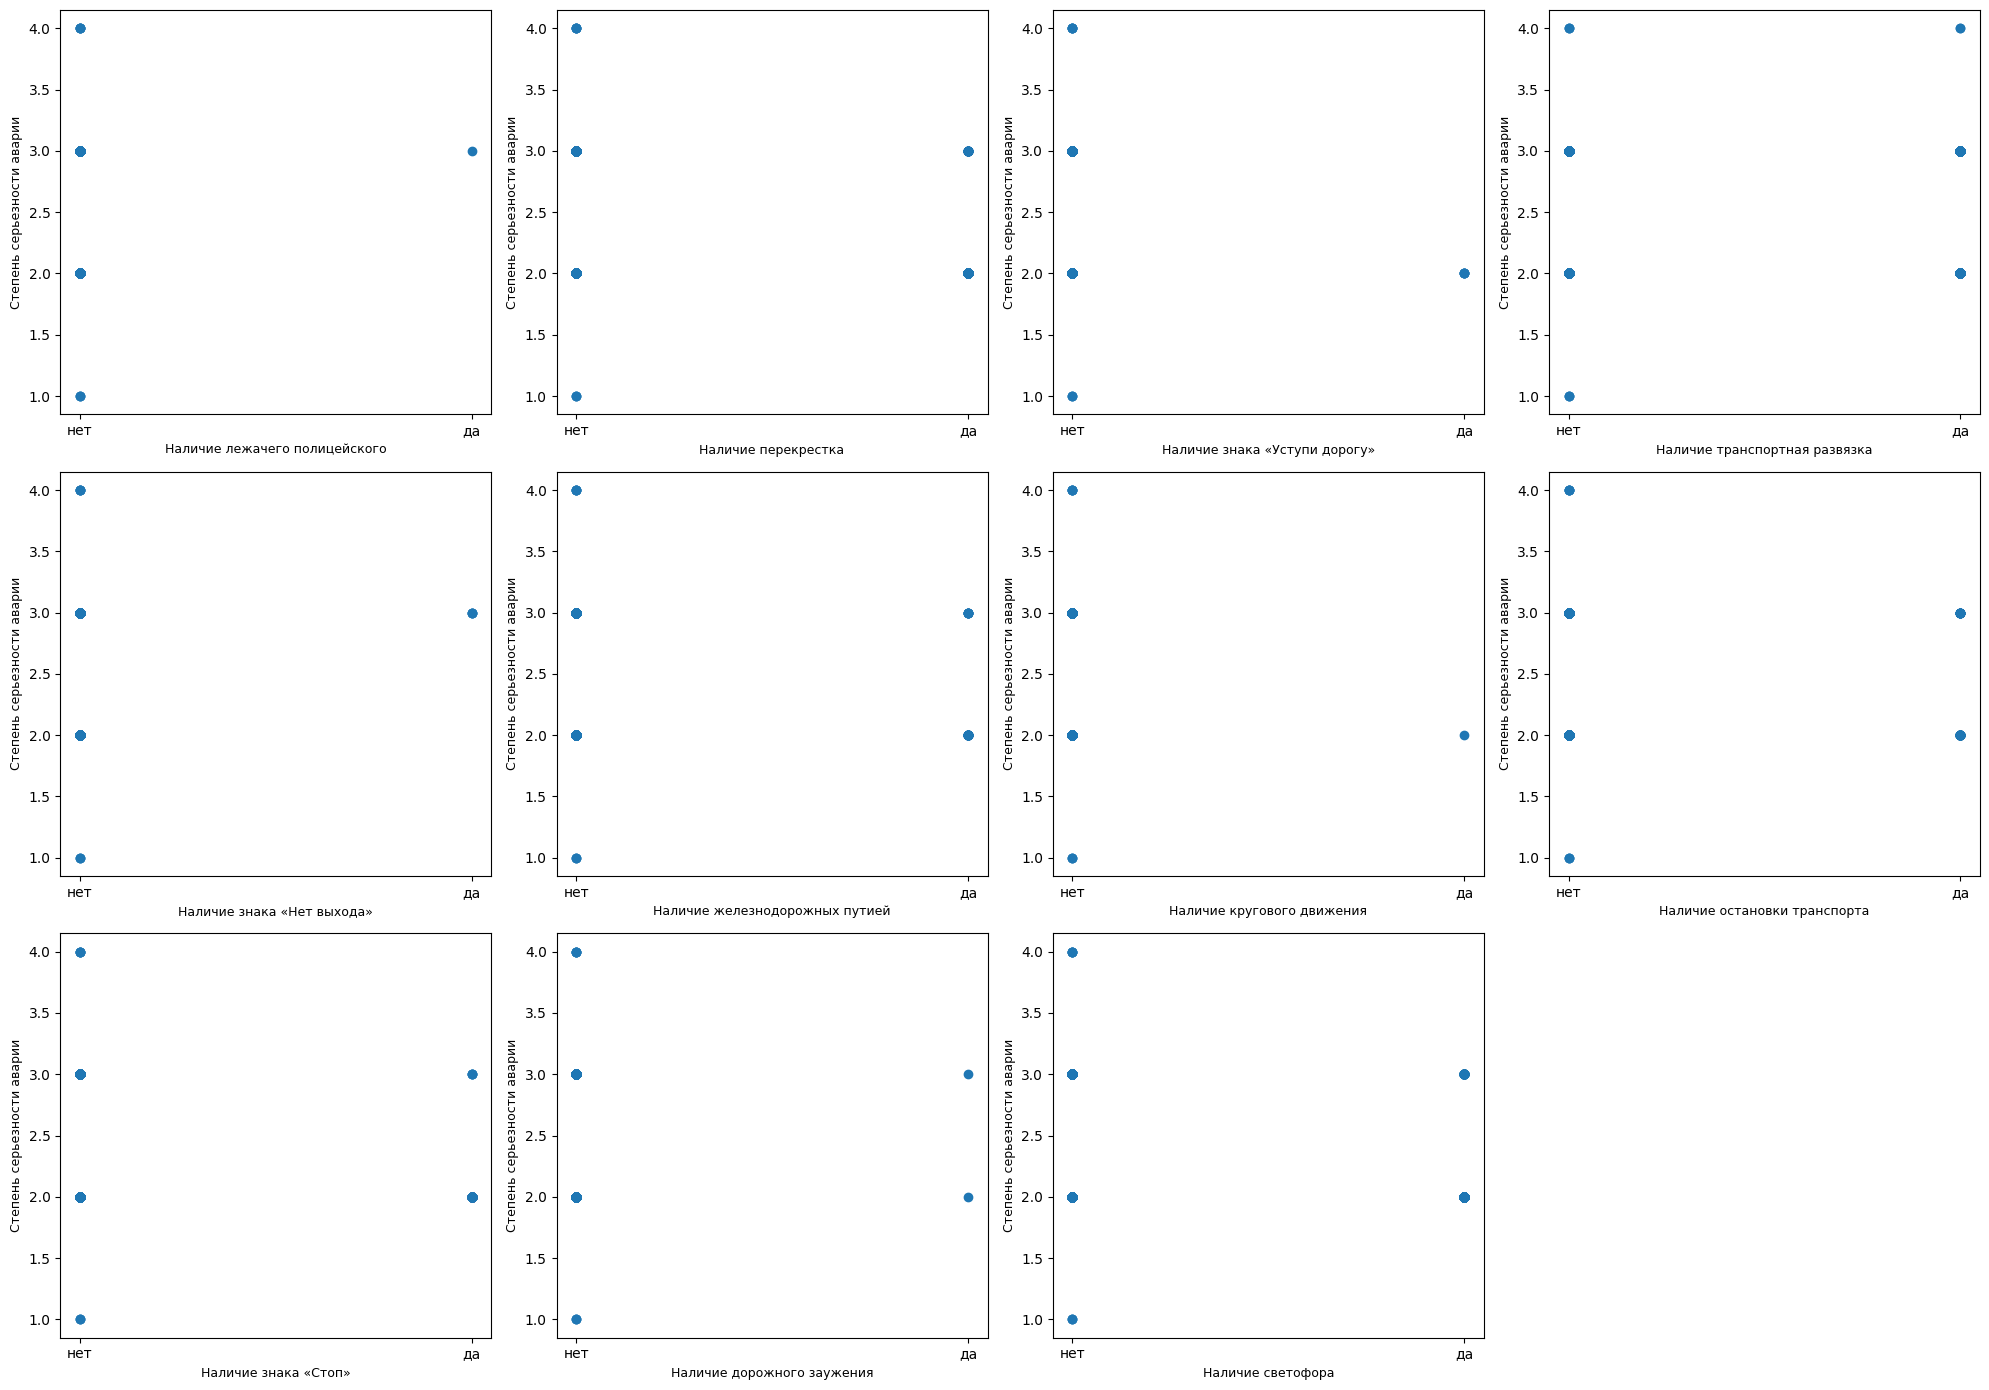

In [ ]:
severity = [toFloat(v) for v in dataByType(filteredData, 3)]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for k, i in enumerate(q_ind):
    r, c = divmod(k, 4)
    x = [1 if str(v).strip().lower() == 'true' else 0
         for v in dataByType(filteredData, i)]
    axes[r][c].scatter(x, severity)
    axes[r][c].set_xlabel(types[i], fontsize=9)
    axes[r][c].set_ylabel("Степень серьезности аварии", fontsize=9)
    axes[r][c].set_xticks([0, 1])
    axes[r][c].set_xticklabels(["нет", "да"])
axes[2][3].set_visible(False)
plt.tight_layout()
plt.show()